<img src="./logo_UNSAM.jpg" align="right" width="250" />  -->
# Análisis y Procesamiento de Señales

## Trabajo Práctico Nº2
#### Sofía Gervasi


# Introducción
El presente trabajo aborda el análisis de dos circuitos lineales con el objetivo de caracterizar su comportamiento. A partir de sus esquemas circuitales, se hallará analíticamente la función de transferencia, y mediante el uso del método gráfico y herramientas de software se determinará y simulará la respuesta en módulo y fase de cada circuito. En base al análisis de los gráficos obtenidos, se clasificará el tipo de filtro que representa cada circuito y se calculará su respectivo ancho de banda.

## Filtro A
<img src="./TS2%20FiltroA.png" width="600">


### A.I. Función de Transferencia y Ancho de Banda

La función de transferencia del circuito, está definida de la siguente forma: 

$$ H(s)=\frac{Vo}{Vi} $$ 

tras el análisis del circuito propuesto queda expresada como

$$ H(s)=\frac{R}{\frac{1}{SC}+SL+R} $$

Simplificando esta expresión, obtenemos

$$ H(s)=\frac{S \frac{R}{L}}{S^2 + S \frac{R}{L} + \frac{1}{LC}} $$

Donde la pulsación natural de la red se define como $\omega_0^2 = \frac{1}{LC}$, y el factor de selectividad como $ \frac{\omega_0}{Q} =\frac{R}{L}$

Sustituyendo estos parámetros en la función de transferencia H(s) y evaluándola en el dominio de la frecuencia (s=jw), obtenemos:

$$ H(jw)=\frac{jw \frac{\omega_0}{Q}}{-w^2 + jw \frac{\omega_0}{Q} + \omega_0 ^2} $$

Conociendo la relación entre el ancho de banda (B) y el factor de calidad (Q) 

$$ B= \frac{\omega_0}{Q} $$

podemos expresar el ancho de banda en términos de los componentes del circuito como

$$ B= \frac{R}{L}$$ 

### A.II. Respuesta de módulo y fase 

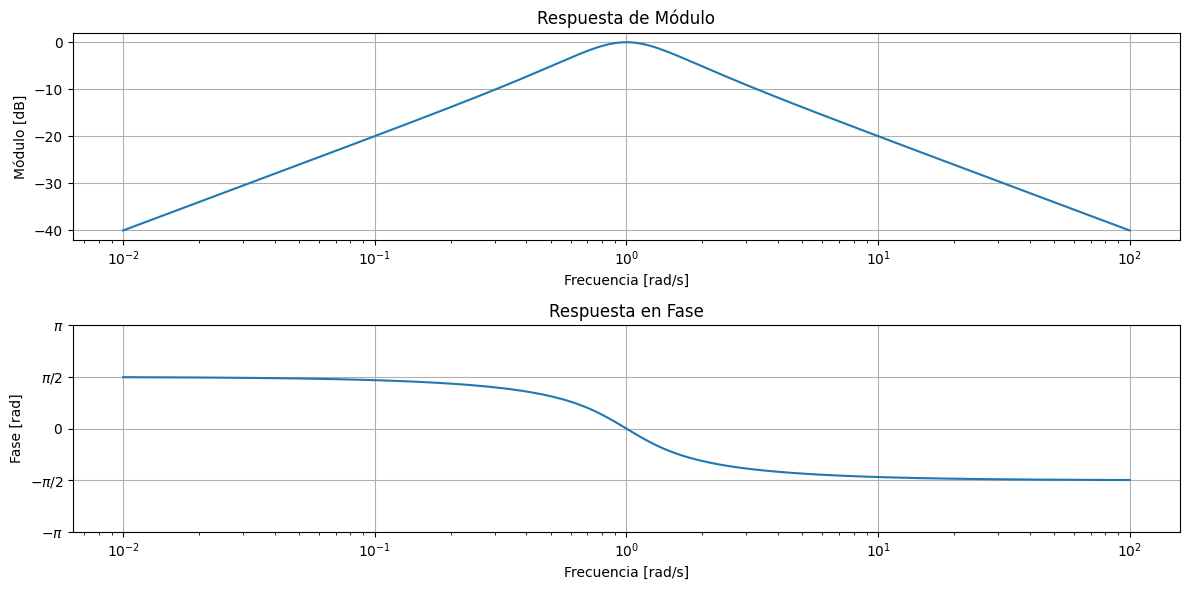

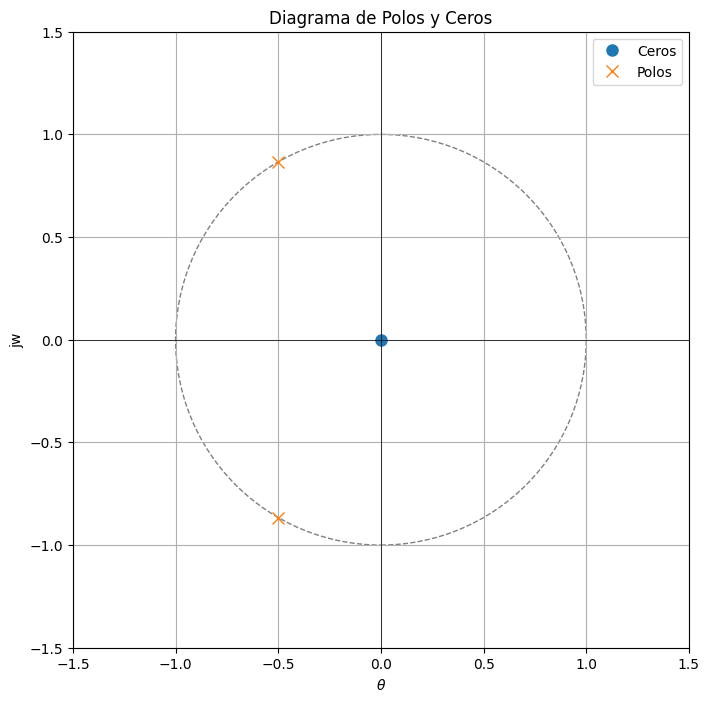

In [8]:
"""
Created on Sat Mar 22 18:50:23 2025

@author: Sofía
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

## Filtro A
#Para fines de la simulación propongo: 
Q = 1
w0 = 1 #rad/s

# Ingreso la funcion transferencia H(s) como vectores 

num = np.array([ w0 / Q, 0 ])
den = np.array([ 1., w0 / Q, w0**2 ])

# Creo la función de transferencia
H = sig.TransferFunction(num, den)

# Especifico las frecuencias a evaluar
frec = np.logspace(-2, 2, 200)  # Frecuencias en rad/s

# Respuesta de módulo y fase
w, mag, fase = sig.bode(H, frec)

# Convierto la fase de grados a radianes
faser = np.deg2rad(fase)

#Busco polos y ceros
ceros, polos, _= sig.tf2zpk(num, den)

# Gráfico de la respuesta de módulo (en dB)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.semilogx(w, mag)
plt.title("Respuesta de Módulo")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Módulo [dB]")
plt.grid(True)

# Gráfico de la respuesta en fase (en grados)
plt.subplot(2, 1, 2)
plt.semilogx(w, faser)
plt.title("Respuesta en Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [rad]")
plt.yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$']) 
plt.grid(True)


plt.tight_layout()
plt.show()

# Graficar los ceros y los polos

plt.figure(figsize=(8, 8))
ax = plt.gca()

plt.plot(ceros.real, ceros.imag, 'o', markersize=8, label='Ceros')
plt.plot(polos.real, polos.imag, 'x', markersize=8, label='Polos')

# Dibujar el círculo unitario 
unit_circle = plt.Circle((0, 0), radius=1, fill=False, color='gray', linestyle='--')
ax.add_artist(unit_circle)

# Configurar los ejes
plt.axvline(0, color='black', linewidth=0.5)  # Eje imaginario
plt.axhline(0, color='black', linewidth=0.5)  # Eje real

# Establecer límites para los ejes (ajustar según la ubicación de polos y ceros)
max_val = max(np.max(np.abs(polos)), np.max(np.abs(ceros)), 1.5) 
plt.xlim([-max_val, max_val])
plt.ylim([-max_val, max_val])

# Añadir etiquetas y título
plt.xlabel(r'$\theta$')
plt.ylabel("jw")
plt.title('Diagrama de Polos y Ceros')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Asegurar que el círculo unitario sea circular
plt.show()


## Filtro B
<img src="./TS2%20FiltroB.png" width="600">

### B.I. Función de Transferencia y Ancho de Banda

Análogamente con el caso anterior, se plantea:

$$ H(s)=\frac{Vo}{Vi} $$

$$ Vi= \frac{1}{SC} + \frac{SLR}{SL+R}= \frac{SL+R+S^2LRC}{SC(SL+R)} $$

$$ Vo= \frac{SLR}{SL+R} $$

$$ H(s)=\frac{S^2LRC}{S^2LRC+SL+R}$$ 

$$ H(s)=\frac{S^2}{S^2+ \frac{S}{RC} + \frac{1}{LC}}$$ 

$$ H(jw) = \frac{-w^2}{-w^2 + jw \frac{\omega_0}{Q} + \omega_0 ^2} $$

$$ B= \frac{1}{RC}$$ 

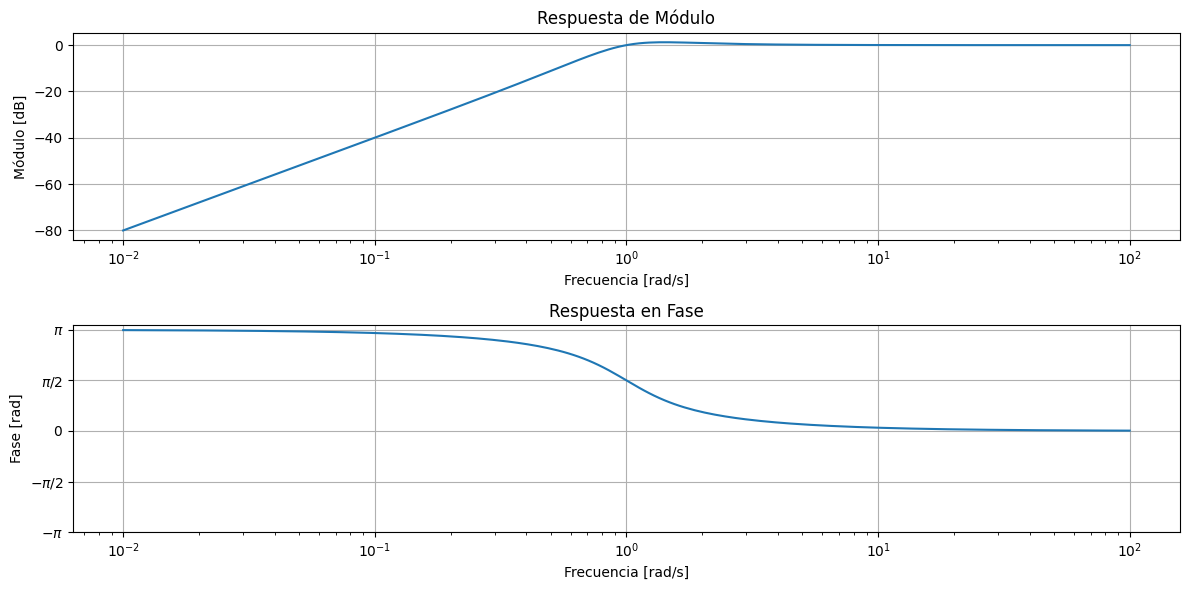

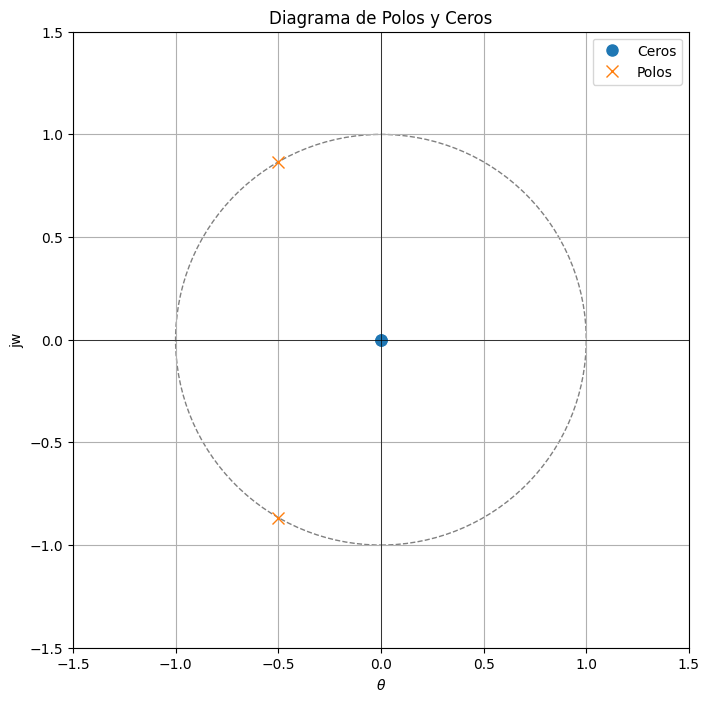

In [6]:
## Filtro B
#Propongo
Q = 1
w0 = 1 #rad/s

# Ingreso la funcion transferencia H(s) como vectores 

num = np.array([ 1,0,0])
den = np.array([ 1., w0 / Q, w0**2 ])

# Creo la función de transferencia
H = sig.TransferFunction(num, den)

# Especifico las frecuencias a evaluar
frec = np.logspace(-2, 2, 200)  # Frecuencias en rad/s

# Respuesta de módulo y fase
w, mag, fase = sig.bode(H, frec)

# Convierto la fase de grados a radianes
faser = np.deg2rad(fase)

#Busco polos y ceros
ceros, polos, _= sig.tf2zpk(num, den)

# Gráfico de la respuesta de módulo (en dB)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.semilogx(w, mag)
plt.title("Respuesta de Módulo")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Módulo [dB]")
plt.grid(True)

# Gráfico de la respuesta en fase (en grados)
plt.subplot(2, 1, 2)
plt.semilogx(w, faser)
plt.title("Respuesta en Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [rad]")
plt.yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$']) 
plt.grid(True)


plt.tight_layout()
plt.show()

# Graficar los ceros y los polos

plt.figure(figsize=(8, 8))
ax = plt.gca()

plt.plot(ceros.real, ceros.imag, 'o', markersize=8, label='Ceros')
plt.plot(polos.real, polos.imag, 'x', markersize=8, label='Polos')

# Dibujar el círculo unitario 
unit_circle = plt.Circle((0, 0), radius=1, fill=False, color='gray', linestyle='--')
ax.add_artist(unit_circle)

# Configurar los ejes
plt.axvline(0, color='black', linewidth=0.5)  # Eje imaginario
plt.axhline(0, color='black', linewidth=0.5)  # Eje real

# Establecer límites para los ejes (ajustar según la ubicación de polos y ceros)
max_val = max(np.max(np.abs(polos)), np.max(np.abs(ceros)), 1.5) 
plt.xlim([-max_val, max_val])
plt.ylim([-max_val, max_val])

# Añadir etiquetas y título
plt.xlabel(r'$\theta$')
plt.ylabel("jw")
plt.title('Diagrama de Polos y Ceros')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Asegurar que el círculo unitario sea circular
plt.show()

# Conclusión

Tras analizar las funciones de transferencia se concluye que el Filtro A corresponde a un pasa banda de segundo orden, mientras que el Filtro B se identifica como un pasa alto, también de segundo orden. Esta clasificación puede corroborarse al examinar los gráficos de simulación, donde se observa que el Filtro A atenúa las frecuencias tanto muy bajas como muy altas, permitiendo el paso de un rango intermedio. Por otro lado, el Filtro B atenúa principalmente las frecuencias más bajas, dejando pasar las frecuencias altas. 
